## Import libs

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.data import Dataset
import seaborn as sns


from models.unfair_lr.models import UnfairLogisticRegression
from models.unfair_lr.learning import train_loop
from util.evaluation import *
from util.load_data import load_data

/Users/lffpl/Projects/falsb/env/falsb/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Preliminaries

In [2]:
batch_size = 64
epochs = 100
lr = 0.001

In [3]:
cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'balanced-stroke'

In [5]:
x, y, a = load_data(data_name)
raw_data = (x, y, a)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
adim = a.shape[1]
zdim = 8

## Result file

In [7]:
header = "model_name", "cv_seed", "clas_acc", "dp", "deqodds", "deqopp", "trade_dp", "trade_deqodds", "trade_deqopp", "TN_a0", "FP_a0", "FN_a0", "TP_a0", "TN_a1", "FP_a1", "FN_a1", "TP_a1"
results = []

## Testing

In [8]:
for cv_seed in cv_seeds:
    x_train, x_test, y_train, y_test, a_train, a_test = train_test_split(
        x, y, a, test_size=0.3, random_state=cv_seed)

    train_data = Dataset.from_tensor_slices((x_train, y_train, a_train))
    train_data = train_data.batch(batch_size, drop_remainder=True)

    test_data = Dataset.from_tensor_slices((x_test, y_test, a_test))
    test_data = test_data.batch(batch_size, drop_remainder=True)

    # train below

    model = UnfairLogisticRegression(xdim, ydim, batch_size)
    ret = train_loop(model, train_data, epochs)
    Y, A, Y_hat = evaluation(model, test_data)
    
    clas_acc, dp, deqodds, deqopp, confusion_matrix, metrics_a0, metrics_a1  = compute_metrics(Y, A, Y_hat, adim=adim)
    
    fair_metrics = (dp, deqodds, deqopp)
    
    tradeoff = []
    
    for fair_metric in fair_metrics:
        tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
    
    result = ['UnfairLR-decay', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]] + metrics_a0 + metrics_a1

    results.append(result)

> Epoch | Class Loss | Class Acc


2026-01-03 10:20:23.887748: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 1 | 0.6425338983535767 | 0.5159313725490197


2026-01-03 10:20:24.383452: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 2 | 0.6228731870651245 | 0.6400122549019608
> 3 | 0.6131981611251831 | 0.6741727941176471


...

> 64 | 0.5259009599685669 | 0.811734068627451
> 65 | 0.5255095958709717 | 0.8123468137254902
> 66 | 0.5251248478889465 | 0.8128063725490197
> 67 | 0.5247465968132019 | 0.8135723039215687
> 68 | 0.5243746638298035 | 0.8137254901960784
> 69 | 0.5240087509155273 | 0.8137254901960784
> 70 | 0.523648738861084 | 0.8143382352941176
> 71 | 0.5232943892478943 | 0.8144914215686274
> 72 | 0.5229455232620239 | 0.8143382352941176
> 73 | 0.5226020812988281 | 0.8146446078431373
> 74 | 0.5222638845443726 | 0.8146446078431373
> 75 | 0.5219308137893677 | 0.8147977941176471
> 76 | 0.5216026306152344 | 0.8151041666666666
> 77 | 0.5212792158126831 | 0.8155637254901961
> 78 | 0.5209605693817139 | 0.8158700980392157
> 79 | 0.520646333694458 | 0.8160232843137255
> 80 | 0.5203366279602051 | 0.8163296568627451
> 81 | 0.5200310945510864 | 0.8166360294117647
> 82 | 0.5197299122810364 | 0.8169424019607843
> 83 | 0.5194326639175415 | 0.8169424019607843
> 84 | 0.5191394686698914 | 0.8174019607843137
> 85 | 0.5188501

2026-01-03 10:21:26.575320: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 27 | 0.5047863721847534 | 0.7977941176470589
> 28 | 0.5037754774093628 | 0.7993259803921569
> 29 | 0.5028052926063538 | 0.7997855392156863
> 30 | 0.5018729567527771 | 0.8003982843137255
> 31 | 0.5009757280349731 | 0.8008578431372549
> 32 | 0.5001112222671509 | 0.8013174019607843
> 33 | 0.4992772340774536 | 0.8016237745098039
> 34 | 0.498471736907959 | 0.8020833333333334
> 35 | 0.49769291281700134 | 0.8019301470588235
> 36 | 0.4969392418861389 | 0.8030024509803921
> 37 | 0.49620917439460754 | 0.8031556372549019
> 38 | 0.4955012798309326 | 0.803921568627451
> 39 | 0.4948144555091858 | 0.8053002450980392
> 40 | 0.4941474199295044 | 0.8056066176470589
> 41 | 0.49349915981292725 | 0.8060661764705882
> 42 | 0.49286869168281555 | 0.8066789215686274
> 43 | 0.4922550916671753 | 0.8069852941176471
> 44 | 0.4916575253009796 | 0.8082107843137255
> 45 | 0.491075336933136 | 0.8086703431372549
> 46 | 0.4905076026916504 | 0.8091299019607843
> 47 | 0.48995375633239746 | 0.8097426470588235
> 48 | 0.48

2026-01-03 10:22:28.826838: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 54 | 0.5668658018112183 | 0.8149509803921569
> 55 | 0.566509485244751 | 0.8152573529411765
> 56 | 0.5661600828170776 | 0.8155637254901961
> 57 | 0.5658172369003296 | 0.8155637254901961
> 58 | 0.5654808282852173 | 0.8157169117647058
> 59 | 0.5651504993438721 | 0.8157169117647058
> 60 | 0.5648261904716492 | 0.8152573529411765
> 61 | 0.5645074844360352 | 0.8154105392156863
> 62 | 0.5641944408416748 | 0.8157169117647058
> 63 | 0.5638867616653442 | 0.8157169117647058
> 64 | 0.5635842084884644 | 0.8161764705882353
> 65 | 0.5632866024971008 | 0.8167892156862745
> 66 | 0.5629938840866089 | 0.8164828431372549
> 67 | 0.5627058744430542 | 0.8167892156862745
> 68 | 0.562422513961792 | 0.8170955882352942
> 69 | 0.5621435046195984 | 0.8172487745098039
> 70 | 0.5618687868118286 | 0.8170955882352942
> 71 | 0.5615981817245483 | 0.8174019607843137
> 72 | 0.5613316893577576 | 0.8180147058823529
> 73 | 0.561069130897522 | 0.8187806372549019
> 74 | 0.560810387134552 | 0.8190870098039216
> 75 | 0.56055545

<Axes: >

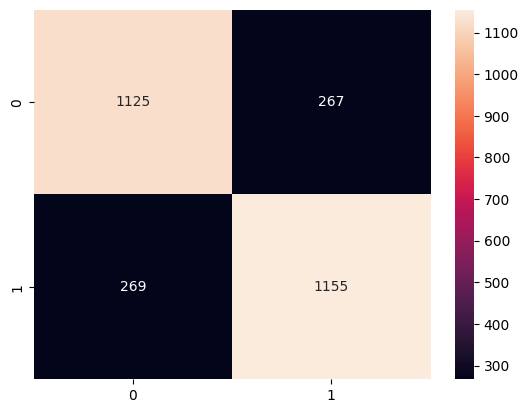

In [9]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

In [10]:
for cv_seed in cv_seeds:
    x_train, x_test, y_train, y_test, a_train, a_test = train_test_split(
        x, y, a, test_size=0.3, random_state=cv_seed)

    train_data = Dataset.from_tensor_slices((x_train, y_train, a_train))
    train_data = train_data.batch(batch_size, drop_remainder=True)

    test_data = Dataset.from_tensor_slices((x_test, y_test, a_test))
    test_data = test_data.batch(batch_size, drop_remainder=True)

    # train below

    opt = Adam(learning_rate=lr)

    model = UnfairLogisticRegression(xdim, ydim, batch_size)
    ret = train_loop(model, train_data, epochs, opt)
    Y, A, Y_hat = evaluation(model, test_data)
    
    clas_acc, dp, deqodds, deqopp, confusion_matrix, metrics_a0, metrics_a1  = compute_metrics(Y, A, Y_hat, adim=adim)
    
    fair_metrics = (dp, deqodds, deqopp)
    
    tradeoff = []
    
    for fair_metric in fair_metrics:
        tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
    
    result = ['UnfairLR', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]] + metrics_a0 + metrics_a1

    results.append(result)

    del(opt)

> Epoch | Class Loss | Class Acc
> 1 | 0.6425338983535767 | 0.5159313725490197
> 2 | 0.6130959391593933 | 0.6544117647058824
> 3 | 0.585159182548523 | 0.7120098039215687
> 4 | 0.5585497617721558 | 0.7565870098039216
> 5 | 0.5343823432922363 | 0.7881433823529411
> 6 | 0.5127524137496948 | 0.8134191176470589


2026-01-03 10:24:33.011966: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 7 | 0.49343711137771606 | 0.8276654411764706
> 8 | 0.4761533737182617 | 0.8397671568627451
> 9 | 0.4606306552886963 | 0.8484987745098039
> 10 | 0.4466293454170227 | 0.8553921568627451
> 11 | 0.4339436888694763 | 0.8602941176470589
> 12 | 0.422399640083313 | 0.8635110294117647
> 13 | 0.4118506908416748 | 0.8661151960784313
> 14 | 0.4021736681461334 | 0.8694852941176471
> 15 | 0.3932649493217468 | 0.8711703431372549
> 16 | 0.38503697514533997 | 0.8743872549019608
> 17 | 0.3774154484272003 | 0.8769914215686274
> 18 | 0.3703368902206421 | 0.8785232843137255
> 19 | 0.3637467622756958 | 0.8805147058823529
> 20 | 0.35759788751602173 | 0.8815870098039216
> 21 | 0.3518493175506592 | 0.8838848039215687
> 22 | 0.34646522998809814 | 0.8863357843137255
> 23 | 0.3414141535758972 | 0.8884803921568627
> 24 | 0.33666813373565674 | 0.8887867647058824
> 25 | 0.33220231533050537 | 0.8904718137254902
> 26 | 0.32799479365348816 | 0.8916973039215687
> 27 | 0.3240257501602173 | 0.8926164215686274
> 28 | 0.3

<Axes: >

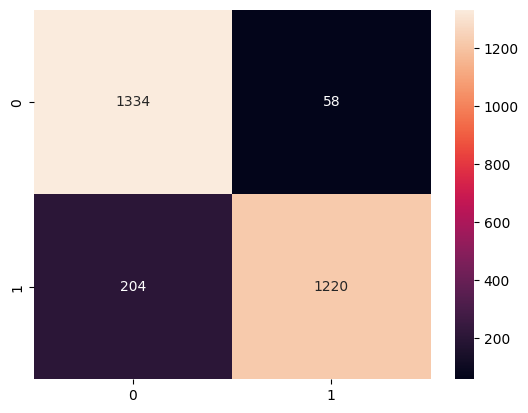

In [11]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [12]:
result_df = pd.DataFrame(results, columns=header)
result_df

,model_name,cv_seed,clas_acc,dp,deqodds,deqopp,trade_dp,trade_deqodds,trade_deqopp,TN_a0,FP_a0,FN_a0,TP_a0,TN_a1,FP_a1,FN_a1,TP_a1
0,UnfairLR-decay,13,0.828835,0.645521,0.781549,0.759782,0.725782,0.804498,0.792808,762.0,81.0,167.0,359.0,401.0,166.0,68.0,812.0
1,UnfairLR-decay,29,0.821023,0.641297,0.764355,0.726453,0.720115,0.791676,0.770848,719.0,79.0,185.0,347.0,410.0,173.0,67.0,836.0
2,UnfairLR-decay,42,0.826705,0.635124,0.763971,0.712044,0.718360,0.794101,0.765102,765.0,68.0,197.0,337.0,420.0,152.0,71.0,806.0
3,UnfairLR-decay,55,0.824929,0.649387,0.776342,0.739577,0.726707,0.799898,0.779925,721.0,86.0,160.0,324.0,443.0,184.0,63.0,835.0
4,UnfairLR-decay,73,0.809659,0.621076,0.741586,0.707206,0.702939,0.774129,0.754973,722.0,77.0,193.0,320.0,403.0,190.0,76.0,835.0
5,UnfairLR,13,0.909446,0.757967,0.937821,0.909929,0.826826,0.923415,0.909688,805.0,38.0,94.0,432.0,522.0,45.0,78.0,802.0
6,UnfairLR,29,0.897727,0.765813,0.927904,0.911771,0.826540,0.912566,0.904694,740.0,58.0,87.0,445.0,508.0,75.0,68.0,835.0
7,UnfairLR,42,0.899503,0.750982,0.918391,0.884578,0.818560,0.908849,0.891978,800.0,33.0,114.0,420.0,522.0,50.0,86.0,791.0
8,UnfairLR,55,0.897727,0.777706,0.944699,0.932370,0.833418,0.920614,0.914721,740.0,67.0,71.0,413.0,548.0,79.0,71.0,827.0
9,UnfairLR,73,0.906960,0.748216,0.918815,0.879617,0.819976,0.912849,0.893080,780.0,19.0,113.0,400.0,554.0,39.0,91.0,820.0


In [13]:
result_df.to_csv(f'{data_name}-result/unfair_lr-{epochs}.csv')